# Test ispezione, filtri, raffinamento e marcatura

Workflow:
1. import del modulo;
2. set parametri di tuning;
3. inizializzazione ZED/robot;
4. singolo scatto;
5. tuning filtri;
6. ispezione globale;
7. raffinamento;
8. marcatura controllata;
9. chiusura sicura.

## 0 — Import del modulo

Questa cella importa `inspection_and_marking.py`.

`importlib.reload(im)` serve per ricaricare il file `.py` se lo modifichi in VSCode durante la sessione notebook.

**Nota:** dopo `reload`, i parametri tornano ai valori scritti nel file `.py`, quindi la cella successiva li risetta per il tuning.

In [1]:
import importlib
import cv2
import numpy as np
import time

import inspection_and_marking as im
import Variables as vb

import matplotlib.pyplot as plt

im = importlib.reload(im)

print("Modulo inspection_and_marking importato e ricaricato.")

Modulo inspection_and_marking importato e ricaricato.


## 1 — Parametri tuning

Modifica questa cella durante i test.

Questi valori vengono scritti dentro il modulo importato `im`, quindi le funzioni `im.inspection_phase(...)`, `im.refine_defect_position(...)`, ecc. useranno questi parametri.

In [2]:
# =====================================================
# MODALITÀ DETECTION
# =====================================================

# False = difetto verde classico
# True  = difetto generico con maschera inversa
im.GENERIC_DETECTION = False


# =====================================================
# ROBOT
# =====================================================

IP_LAB = "192.168.1.3"
IP_SIM = "127.0.0.1"

# Cambia qui se vuoi usare simulazione o robot reale
im.IP_ROBOT = IP_LAB


# =====================================================
# PARAMETRI ISPEZIONE
# =====================================================

im.INSPECTION_RADIUS = 300
im.HUB_ANGLES = (0, 90)

# Evitiamo alpha = ±90 esatti.
# Usiamo ±87 oppure ±85 per evitare problemi geometrici/numerici.
im.INSPECTION_ANGLES = [
    (0,    90,  True),     # hub iniziale
    (0,    90,  False),    # scatto dall'alto
    (0,    45,  False),    # scatto frontale/intermedio
    (87,   60,  False),    # scatto laterale, evita +90
    (-87,  60,  False),    # scatto laterale opposto, evita -90
    (0,    90,  True),     # hub finale
]

im.INSPECTION_SPEED = 300
im.MARKING_SPEED = 50

im.CLOSE_INSPECTION_RADIUS = 400
im.N_CLOSE_SHOTS = 10

im.DUPLICATE_THRESHOLD = 25.0
im.ASSOCIATION_THRESHOLD = 30.0
im.MIN_APPROACH_RADIUS = 400


# =====================================================
# PARAMETRI FILTRI / TUNING
# =====================================================

# Ispezione globale:
# None = considera tutta l'immagine.
im.GLOBAL_ATTENTION_RADIUS = None
im.GLOBAL_CYLINDER_RADIUS = 220.0
im.GLOBAL_HEIGHT_RANGE = (150, 700)

# Raffinamento:
# il difetto dovrebbe essere centrato, quindi attention_radius è attivo.
im.REFINE_ATTENTION_RADIUS = 250
im.REFINE_CYLINDER_RADIUS = 150.0
im.REFINE_HEIGHT_RANGE = (100, 300)

# Filtro globale rispetto al centro casco.
# Tenerlo False finché HELMET_CENTER_GLOBAL non è verificato bene.
im.USE_GLOBAL_POSITION_FILTER = False


print("Parametri laboratorio impostati.")
print("GENERIC_DETECTION:", im.GENERIC_DETECTION)
print("INSPECTION_ANGLES:", im.INSPECTION_ANGLES)
print("GLOBAL_CYLINDER_RADIUS:", im.GLOBAL_CYLINDER_RADIUS)
print("GLOBAL_HEIGHT_RANGE:", im.GLOBAL_HEIGHT_RANGE)
print("REFINE_ATTENTION_RADIUS:", im.REFINE_ATTENTION_RADIUS)
print("REFINE_CYLINDER_RADIUS:", im.REFINE_CYLINDER_RADIUS)
print("REFINE_HEIGHT_RANGE:", im.REFINE_HEIGHT_RANGE)

Parametri laboratorio impostati.
GENERIC_DETECTION: False
INSPECTION_ANGLES: [(0, 90, True), (0, 90, False), (0, 45, False), (87, 60, False), (-87, 60, False), (0, 90, True)]
GLOBAL_CYLINDER_RADIUS: 220.0
GLOBAL_HEIGHT_RANGE: (150, 700)
REFINE_ATTENTION_RADIUS: 250
REFINE_CYLINDER_RADIUS: 150.0
REFINE_HEIGHT_RANGE: (100, 300)


## 2 — Utility leggere per il notebook

Servono solo a stampare meglio i risultati nel notebook.

In [3]:
def print_defects(defect_list, title="Difetti rilevati"):
    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)

    if len(defect_list) == 0:
        print("Nessun difetto rilevato.")
        return

    for i, d in enumerate(defect_list):
        print(f"\nDifetto {i + 1}")

        if hasattr(d, "centroid"):
            print("  centroid:", d.centroid)

        if getattr(d, "pos3d_camera", None) is not None:
            pos_cam = d.pos3d_camera
            radial_camera = np.sqrt(pos_cam[0]**2 + pos_cam[1]**2)
            print("  pos3d_camera:", np.round(pos_cam, 1))
            print(f"  Z camera: {pos_cam[2]:.1f} mm")
            print(f"  radial camera: {radial_camera:.1f} mm")
        else:
            print("  pos3d_camera: None")

        if getattr(d, "pos3d_global", None) is not None:
            print("  pos3d_global:", np.round(d.pos3d_global, 1))
        else:
            print("  pos3d_global: None")


def get_live_H_cam_to_global(controller):
    H_cam_to_ee = im.kin.create_homogeneous_matrix(im.vb.CAMERA_POSE_EE)

    ee_pose_live = controller.robot.tcp_coord
    H_ee_to_global = im.kin.create_homogeneous_matrix(ee_pose_live)
    H_cam_to_global = H_ee_to_global @ H_cam_to_ee

    return H_cam_to_global, ee_pose_live


def show_debug(bgr_image, defect_list, wait_ms=100):
    debug_img, mask_bgr = im.draw_multiple_debug(
        bgr_image,
        defect_list,
        show_global=True
    )

    #cv2.imshow(im.WINDOW_NAME_MASK, mask_bgr)
    #cv2.imshow(im.WINDOW_NAME_RGB, debug_img)
    #cv2.waitKey(wait_ms)

    plt.imshow(cv2.cvtColor(debug_img, cv2.COLOR_BGR2RGB))
    plt.title("Debug Image")
    plt.axis('off')
    plt.show()
    

    return debug_img, mask_bgr

## 3 — Inizializzazione solo ZED

Usa questa cella se vuoi testare solo la camera.

Non muove il robot.

In [4]:
zed, runtime, image_zed, point_cloud = im.init_zed()

#cv2.namedWindow(im.WINDOW_NAME_RGB)
#cv2.namedWindow(im.WINDOW_NAME_MASK)

print("ZED inizializzata.")

ZED inizializzata.


## 4 — Inizializzazione robot + ZED

**Attenzione: muove il robot** verso la posizione iniziale.

In [5]:
controller = im.RobotController(
    ip_address=im.IP_ROBOT,
    default_position_j=vb.LOOK_DOWN_POSITION_J_INIZIO
)

controller.disconnect()  # Assicurati di essere disconnesso prima di connetterti
controller.connect()
print("Robot connesso.")

# Se non hai già inizializzato la ZED nella cella precedente, lascia questa parte attiva.
if "zed" not in globals():
    zed, runtime, image_zed, point_cloud = im.init_zed()
    print("ZED inizializzata.")
else:
    print("ZED già inizializzata.")

try:
    cv2.namedWindow(im.WINDOW_NAME_RGB)
    cv2.namedWindow(im.WINDOW_NAME_MASK)
except Exception:
    pass

controller.default_positioning()
print("Robot in posizione iniziale.")

[18:12:08] INFO     Succesfully connected to robot Ethernet Slave and Modbus.                         techman.py:25

[18:12:09] INFO     Connected to Listen Node                                                          techman.py:37

Robot connesso.
ZED già inizializzata.
Robot in posizione iniziale.


## 5 — Singolo scatto dalla posa attuale

Il robot **non si muove**.

Serve per testare:
- detection verde/generica;
- `attention_radius`;
- filtro cilindrico;
- `height_range`;
- coordinate 3D camera/globali.

In [ ]:
H_cam_to_global, ee_pose_live = get_live_H_cam_to_global(controller)

print("tcp_coord live:", np.round(ee_pose_live, 2))

defect_list, bgr_image = im.take_defects_global(
    runtime,
    zed,
    image_zed,
    point_cloud,
    H_cam_to_global=H_cam_to_global,

    attention_radius=im.GLOBAL_ATTENTION_RADIUS,

    cylindrical_filter=True,
    radius=im.GLOBAL_CYLINDER_RADIUS,
    height_range=im.GLOBAL_HEIGHT_RANGE,

    position_filtering=im.USE_GLOBAL_POSITION_FILTER,

    generic_detection=im.GENERIC_DETECTION
)

show_debug(bgr_image, defect_list, wait_ms=500)
print_defects(defect_list, title="Singolo scatto - parametri globali")

## 6 — Test rapido tuning filtri

Questa cella prova più combinazioni di `radius` e `height_range`.

Il robot non si muove.

In [ ]:
test_configs = [
    {"name": "largo",   "attention_radius": None, "radius": 250.0, "height_range": (100, 800)},
    {"name": "medio",   "attention_radius": None, "radius": 220.0, "height_range": (150, 700)},
    {"name": "stretto", "attention_radius": 250,  "radius": 150.0, "height_range": (200, 600)},
]

H_cam_to_global, ee_pose_live = get_live_H_cam_to_global(controller)

for cfg in test_configs:
    print("\n" + "#" * 70)
    print("CONFIG:", cfg)
    print("#" * 70)

    defect_list, bgr_image = im.take_defects_global(
        runtime,
        zed,
        image_zed,
        point_cloud,
        H_cam_to_global=H_cam_to_global,

        attention_radius=cfg["attention_radius"],

        cylindrical_filter=True,
        radius=cfg["radius"],
        height_range=cfg["height_range"],

        position_filtering=im.USE_GLOBAL_POSITION_FILTER,

        generic_detection=im.GENERIC_DETECTION
    )

    show_debug(bgr_image, defect_list, wait_ms=700)
    print_defects(defect_list, title=f"Risultati config: {cfg['name']}")

## 7 — Movimento a un waypoint e scatto

Questa cella muove il robot verso una posizione sferica scelta e poi fa uno scatto.

**Attenzione: muove il robot.**

In [6]:
all_def = []

Target sferico: [300   0  90]
  [CIRCLE] Movimento sferico: (1.9°, 124.6°) -> (0.0°, 90.0°)


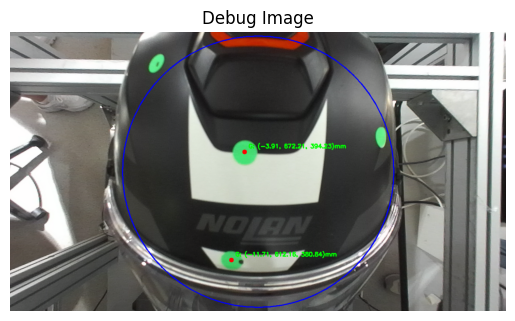


Scatto da waypoint scelto

Difetto 1
  centroid: [571 588]
  pos3d_camera: [-10.6  49.5 160.3]
  Z camera: 160.3 mm
  radial camera: 50.6 mm
  pos3d_global: [-11.7 612.2 380.8]

Difetto 2
  centroid: [605 309]
  pos3d_camera: [ -2.8 -10.5 146.9]
  Z camera: 146.9 mm
  radial camera: 10.9 mm
  pos3d_global: [ -3.9 672.2 394.2]


In [7]:
# Scegli qui il waypoint da testare: [r, alpha, beta]
# Evita alpha = ±90 esatti nei test laterali.
im.INSPECTION_RADIUS = 300
TEST_SPH = np.array([im.INSPECTION_RADIUS, 0, 90])

print("Target sferico:", TEST_SPH)

#confirm = input("Premi INVIO per muovere il robot verso questo waypoint, oppure scrivi no: ")

im.move_circle_spherical(
    controller=controller,
    end_sph_coord=TEST_SPH,
    radius=TEST_SPH[0],
    tool_pose_ee=vb.CAMERA_POSE_EE,
    helmet_center=vb.HELMET_CENTER_GLOBAL,
    speed=im.INSPECTION_SPEED
)
time.sleep(1)

H_cam_to_global, ee_pose_live = get_live_H_cam_to_global(controller)

defect_list, bgr_image = im.take_defects_global(
    runtime,
    zed,
    image_zed,
    point_cloud,
    H_cam_to_global=H_cam_to_global,

    attention_radius= 350,#im.GLOBAL_ATTENTION_RADIUS,

    cylindrical_filter=True,
    radius= 70, #im.GLOBAL_CYLINDER_RADIUS,
    height_range= (120, 300),  #im.GLOBAL_HEIGHT_RANGE,

    position_filtering= False,    #im.USE_GLOBAL_POSITION_FILTER,

    generic_detection= False  #im.GENERIC_DETECTION
    
)

show_debug(bgr_image, defect_list, wait_ms=500)
print_defects(defect_list, title="Scatto da waypoint scelto")

all_def.extend(defect_list)

In [8]:
len(all_def)

2

## 8 — Ispezione globale completa

**Attenzione: muove il robot.**

In [ ]:
confirm = input("Premi INVIO per iniziare ispezione globale, oppure scrivi no: ")

if confirm.lower().strip() != "no":
    unique_defects = im.inspection_phase(
        controller=controller,
        zed=zed,
        runtime=runtime,
        image_zed=image_zed,
        point_cloud=point_cloud,
        helmet_center=vb.HELMET_CENTER_GLOBAL,
        inspection_angles=im.INSPECTION_ANGLES,
        radius=im.INSPECTION_RADIUS,
        generic_detection= True  #im.GENERIC_DETECTION
    )

    print("\nDifetti univoci trovati:", len(unique_defects))
    print_defects(unique_defects, title="Difetti univoci dopo ispezione")
else:
    print("Ispezione annullata.")

## 9 — Raffinamento di un singolo difetto

Usa questa cella dopo l'ispezione globale.

**Attenzione: muove il robot.**

In [9]:
unique_defects = im.duplicate_filter(all_def, 10)

In [13]:
len(unique_defects)

2

In [14]:
# Cambia indice qui: 0 = primo difetto
DEFECT_INDEX = 1

if "unique_defects" not in globals() or len(unique_defects) == 0:
    print("Prima devi eseguire l'ispezione globale e ottenere unique_defects.")
elif DEFECT_INDEX < 0 or DEFECT_INDEX >= len(unique_defects):
    print(f"Indice non valido. Ci sono {len(unique_defects)} difetti.")
else:
    d = unique_defects[DEFECT_INDEX]
    print("Difetto scelto:", np.round(d.pos3d_global, 1))

    confirm = input("Premi INVIO per raffinare questo difetto, oppure scrivi no: ")

    if confirm.lower().strip() != "no":
        # move_circle_spherical dentro refine_defect_position
        # gestisce autonomamente la sicurezza della traiettoria.
        success = im.refine_defect_position(
            controller=controller,
            zed=zed,
            runtime=runtime,
            image_zed=image_zed,
            point_cloud=point_cloud,
            defect_obj=d,
            helmet_center=vb.HELMET_CENTER_GLOBAL,
            generic_detection= True , #im.GENERIC_DETECTION
            close_radius = 300
        )

        print("Success:", success)
        print("Nuova posizione:", np.round(d.pos3d_global, 1))
    else:
        print("Raffinamento annullato.")

Difetto scelto: [ -3.9 672.2 394.2]
  Raffinamento difetto: r_stimato=153.5mm, alpha=-1.0°, beta=86.1°
  Movimento camera a r=300mm nella direzione del difetto.
  [CIRCLE] Movimento sferico: (-10.2°, 117.1°) -> (-1.0°, 86.1°)
    Scatto 1/10: trovato, distanza=0.8mm
      Difetto rilevato 1:
        centroid: [618 359]
        pos3d_camera: [ -0.2  -0.7 146. ]
        Z camera: 146.0 mm
        radial camera: 0.7 mm
        pos3d_global: [ -4.1 672.9 394.6]
    Scatto 2/10: trovato, distanza=0.8mm
      Difetto rilevato 1:
        centroid: [618 359]
        pos3d_camera: [ -0.2  -0.7 146.9]
        Z camera: 146.9 mm
        radial camera: 0.7 mm
        pos3d_global: [ -4.1 672.9 393.7]
    Scatto 3/10: trovato, distanza=0.7mm
      Difetto rilevato 1:
        centroid: [618 359]
        pos3d_camera: [ -0.2  -0.7 146.7]
        Z camera: 146.7 mm
        radial camera: 0.7 mm
        pos3d_global: [ -4.1 672.9 393.9]
    Scatto 4/10: trovato, distanza=0.7mm
      Difetto rilevato 1:

## 10 — Marcatura di un singolo difetto

Usa questa cella solo quando sei sicuro che la posizione sia corretta.

**Attenzione: muove il robot e prova a marcare con il pennarello.**

In [15]:
# Cambia indice qui: 0 = primo difetto
DEFECT_INDEX = 1

if "unique_defects" not in globals() or len(unique_defects) == 0:
    print("Prima devi avere unique_defects.")
elif DEFECT_INDEX < 0 or DEFECT_INDEX >= len(unique_defects):
    print(f"Indice non valido. Ci sono {len(unique_defects)} difetti.")
else:
    d = unique_defects[DEFECT_INDEX]
    print("Difetto scelto per marcatura:", np.round(d.pos3d_global, 1))

    confirm = input("SCRIVI mark PER MARCARE QUESTO DIFETTO: ")

    if confirm.lower().strip() == "mark":
        im.mark_defect(
            controller=controller,
            defect_obj=d,
            helmet_center=vb.HELMET_CENTER_GLOBAL,
            marking_speed=500
        )
    else:
        print("Marcatura annullata.")

Difetto scelto per marcatura: [ -4.1 672.9 394.2]
  Avvio marcatura difetto in [ -4.1 672.9 394.2] mm
    Punto di approccio a r=250.0mm.
    Posa approccio EE: [ -11.6  690.2  629.9 -178.9   -4.2  -90.1]
  [CIRCLE] Movimento sferico: (4.9°, 78.7°) -> (-1.1°, 85.8°)
    Avanzamento lineare al difetto.
    Arretramento lineare.
    Marcatura completata.


## 11 — Pipeline completa: raffinamento + marcatura

**Attenzione: muove il robot e marca tutti i difetti in `unique_defects`.**

In [ ]:
if "unique_defects" not in globals() or len(unique_defects) == 0:
    print("Prima devi eseguire l'ispezione globale e ottenere unique_defects.")
else:
    confirm = input("SCRIVI all PER RAFFINARE E MARCARE TUTTI I DIFETTI: ")

    if confirm.lower().strip() == "all":
        im.refine_and_mark_phase(
            controller=controller,
            zed=zed,
            runtime=runtime,
            image_zed=image_zed,
            point_cloud=point_cloud,
            unique_defects=unique_defects,
            helmet_center=vb.HELMET_CENTER_GLOBAL,
            generic_detection= True  #im.GENERIC_DETECTION
        )
    else:
        print("Pipeline completa annullata.")

## 12 — Chiusura sicura

In [ ]:
try:
    if "controller" in globals():
        controller.default_positioning()
        print("Robot riportato in posizione iniziale.")
except Exception as e:
    print("Errore default_positioning:", e)

try:
    if "controller" in globals():
        controller.disconnect()
        print("Robot disconnesso.")
except Exception as e:
    print("Errore disconnect:", e)

try:
    if "zed" in globals():
        zed.close()
        print("ZED chiusa.")
except Exception as e:
    print("Errore chiusura ZED:", e)

try:
    cv2.destroyAllWindows()
    print("Finestre OpenCV chiuse.")
except Exception as e:
    print("Errore chiusura finestre:", e)